# SGL (Study Group Learning) Vessel Segmentation
This notebook uses the state-of-the-art SGL model (MICCAI 2021) to perform vessel segmentation on 3 random images from Domain A and Domain B.

In [1]:
import os
import sys
sys.path.append('sgl_src')

import torch
import numpy as np
from pathlib import Path
from PIL import Image
from eval_utils import get_test_images, plot_comparison

# SGL imports
from option import args
from model import Model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [2]:
# Setup Paths and Data
DATA_DIR = '../datasets/dlri/aligned'
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

chosen_A, chosen_B = get_test_images(DATA_DIR, num_images=3)
print('Selected A images:', [p.name for p in chosen_A])
print('Selected B images:', [p.name for p in chosen_B])

Selected A images: ['7330_Complete_L_0.png', '1038_Anomalous_R_0.png', '1010_Complete_R_0.png']
Selected B images: ['7330_Complete_L_0.png', '1038_Anomalous_R_0.png', '1010_Complete_R_0.png']


In [3]:
# Load SGL Model
class DummyCheckpoint:
    def __init__(self):
        self.log_file = sys.stdout
    def get_path(self, *args, **kwargs):
        return '.'

args.model = 'CON'
args.pre_train = 'models/sgl/drive_k8.pth'
args.test_only = True
args.cpu = not torch.cuda.is_available()

ckp = DummyCheckpoint()
model = Model(args, ckp)
model.eval()
print('SGL model loaded successfully!')

Making model...
Load the model from models/sgl/drive_k8.pth


MainNet(
  (s1): EnhanceNet(
    (conv1): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): PReLU(num_parameters=1)
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (conv2): Sequential(
      (0): PReLU(num_parameters=1)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): PReLU(num_parameters=1)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (conv3): Sequential(
      (0): PReLU(num_parameters=1)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [4]:
def segment_image_sgl(img_path, model, device):
    img = Image.open(img_path).convert('RGB')
    original_size = img.size # W, H
    
    # Standardize size for model processing (to avoid memory/dimension issues)
    img = img.resize((512, 512))
    
    # Convert to tensor
    img_np = np.array(img).transpose(2,0,1)[np.newaxis, ...] # B,C,H,W
    img_t = torch.tensor(img_np).float()
    if not args.cpu:
        img_t = img_t.to(device)

    with torch.no_grad():
        enh, y = model(img_t, 0) # y is the segmentation output
    
    # Convert back to numpy
    pred = y.cpu().squeeze().numpy()
    if pred.ndim == 3:
        pred = pred[1] # typically class 1 is vessels
    
    # Resize back to original
    pred_img = Image.fromarray((pred * 255).astype(np.uint8))
    pred_img = pred_img.resize(original_size)
    
    # Binarize
    pred_bin = np.array(pred_img) > 128
    return pred_bin

# Run segmentation
print('Running inference on Domain A...')
preds_A = [segment_image_sgl(p, model, device) for p in chosen_A]

print('Running inference on Domain B...')
preds_B = [segment_image_sgl(p, model, device) for p in chosen_B]

Running inference on Domain A...


Running inference on Domain B...


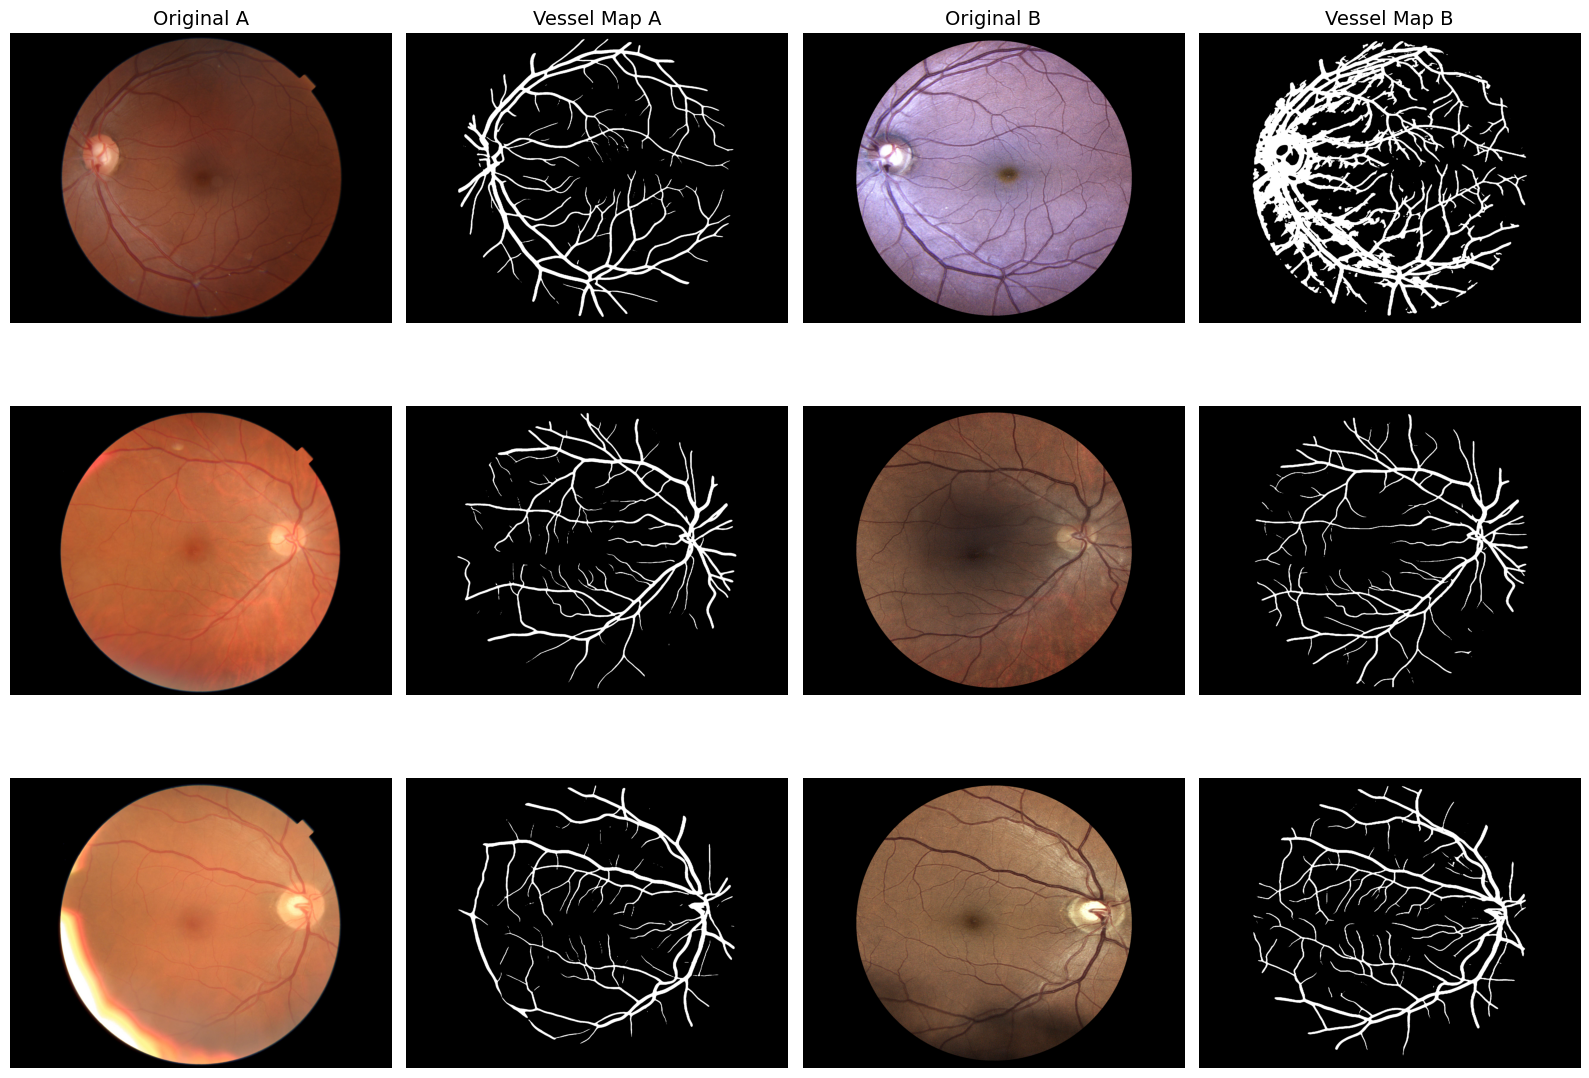

Saved visualization to results/sgl_comparison_plot.png


In [5]:
# Plot and save results
save_path = RESULTS_DIR / 'sgl_comparison_plot.png'
plot_comparison(chosen_A, chosen_B, preds_A, preds_B, save_path)
print(f'Saved visualization to {save_path}')